
<center>

# 💫 **CSCI3237 – Introduction to Machine Learning**

### **Endterm Project**

</center>


# <center><strong><h3>Wine Quality Analysis</h3></strong></center>

<br><br>


<div align="center">

<a href="https://ibb.co.com/B51MBRDP"><img src="https://i.ibb.co.com/67dCF5hZ/image-fix.jpg" alt="image-fix" border="0" width="1200px" style="border-radius: 14px; box-shadow: 0 0 25px rgba(0,180,255,0.45);" /></a>
---

### 👥 **Project Authors**

| Name                   | Role                      |
| ---------------------- | ------------------------- |
| **Anuar Rina**         | Research & Implementation |
| **Ulasova Gaukhar**    | Data Processing           |
| **Karim Adiyar**       | Model Development         |
| **Adylkhanov Alisher** | Evaluation & Testing      |
| **Li Artur**           | Visualization & Report    |

---

### ✨ *A creative journey into the foundations of Machine Learning.*

</div>


---

# <strong>Project Overview</strong>

<h3>This project uses machine learning to predict wine quality based on measurable physicochemical properties of red and white wines. 

By analyzing features such as acidity, sugar content, alcohol percentage, and sulfur compounds, we build models that classify wines into high-quality or low-quality categories.</h3>

---

## Key Features of the Project

- Full data preprocessing and cleaning

- Exploratory data analysis (distributions, correlations, feature patterns)

- Feature scaling, selection, and engineering

- Training and tuning of multiple ML models

- Threshold optimization for improved classification

- Model interpretability through feature importance analysis

---
## Models Used

- Logistic Regression

- k-Nearest Neighbors

- Support Vector Machine

- Random Forest

---


<a id="import"></a>
<h2><b><span style>🍷 Step 1.1 : </span><span>Import Libraries</span></b></h2>

In [174]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

<a id="import"></a>
<h2><b><span style>🍷 Step 1.2 : </span><span>Some set up </span></b></h2>

In [120]:
pd.options.mode.copy_on_write = True #Allow re-write on variable
sns.set_style('darkgrid') #Seaborn style

In [121]:
sns.color_palette("Set2")


[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [122]:
sns.set_palette("Set2")


<h2><b><span style>🍷 Step 2.1 : </span><span>Importing data</span></b></h2>

In [123]:
data = pd.read_csv('./data/wine_quality.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<a id="info"></a>
<h2><b><span>🍷 Step 2.2 : </span><span>Data Information</span></b></h2>

In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [125]:
data.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000000,7.215307,1.296434,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6497.000000,0.339666,0.164636,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6497.000000,0.318633,0.145318,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6497.000000,5.443235,4.757804,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6497.000000,0.056034,0.035034,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6497.000000,30.525319,17.749400,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6497.000000,115.744574,56.521855,6.000000,77.000000,118.000000,156.000000,440.000000
density,6497.000000,0.994697,0.002999,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6497.000000,3.218501,0.160787,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6497.000000,0.531268,0.148806,0.220000,0.430000,0.510000,0.600000,2.000000


**1. Alcohol (% by volume)**  
- Mean: **≈10.5%**  
- Range: **8.0% – 14.9%**  
- 25%: **9.5%** | Median: **10.3%** | 75%: **11.3%**  
- Higher alcohol levels are usually associated with richer body and, often, higher perceived quality.

**2. Volatile acidity** (acetic acid, vinegar-like)  
- Mean: **≈0.34 g/dm³**  
- Range: **0.08 – 1.58**  
- 25%: **0.23** | Median: **0.29** | 75%: **0.40**  
- High values can give unpleasant vinegar notes and typically reduce wine quality.

**3. Residual sugar** (sweetness)  
- Mean: **≈5.4 g/dm³**  
- Range: **0.6 – 65.8**  
- 25%: **1.8** | Median: **3.0** | 75%: **8.1**  
- Distribution is skewed: most wines are relatively dry, with a small number of very sweet wines.

**4. Total sulfur dioxide** (preservatives)  
- Mean: **≈115 mg/dm³**  
- Range: **6 – 440**  
- 25%: **77** | Median: **118** | 75%: **156**  
- Large variation suggests different preservation strategies across producers.

**5. Quality (target variable)**  
- Integer scores from **3 to 9**  
- Mean: **≈5.8**  
- 25%: **5** | Median: **6** | 75%: **6**  
- Most wines are rated as **average to slightly above average**, with relatively few very high-quality samples.

**Summary:** The dataset contains **6 497 wines**. Alcohol, volatile acidity, residual sugar, total sulfur dioxide and quality will be the main variables of interest for modelling and interpretation.

In [126]:
data = data.drop_duplicates()

In [127]:
data.shape

(5320, 13)

<a id="info"></a>
<h2><b><span>🍷 Step 2.3 : </span><span>Features Information</span></b></h2>

| #  | Feature               | Type    | Meaning / Description                                                   | Interpretation in wine context                                             |
|----|-----------------------|---------|-------------------------------------------------------------------------|----------------------------------------------------------------------------|
| 0  | fixed acidity         | float64 | Non-volatile (fixed) acids: tartaric, malic, etc.                      | Main component of total acidity; affects freshness and structure           |
| 1  | volatile acidity      | float64 | Volatile acids, mainly acetic acid                                     | High values give vinegar-like smell/taste and lower perceived quality      |
| 2  | citric acid           | float64 | Citric acid                                                            | Adds freshness and brightness; affects acidity balance                     |
| 3  | residual sugar        | float64 | Remaining sugar after fermentation                                     | Determines sweetness level (dry vs semi-sweet vs sweet)                    |
| 4  | chlorides             | float64 | Salt content (mostly sodium chloride)                                  | High levels can lead to salty/flat taste and lower quality                 |
| 5  | free sulfur dioxide   | float64 | Free SO₂ (active, unbound form)                                        | Acts as antioxidant/preservative; excessive levels give sharp SO₂ smell    |
| 6  | total sulfur dioxide  | float64 | Total SO₂ (free + bound)                                               | Affects shelf life and microbial stability; too high can be a defect       |
| 7  | density               | float64 | Density of the wine                                                    | Related to sugar and alcohol; indirectly reflects style and composition    |
| 8  | pH                    | float64 | Acidity on the pH scale                                                | Lower pH → more acidic, fresher, and more stable; higher pH → softer taste |
| 9  | sulphates             | float64 | Sulphate compounds (e.g., potassium sulphate)                          | Influence structure and mouthfeel; linked to sulfur dioxide management     |
| 10 | alcohol               | float64 | Alcohol content (% by volume)                                          | Often positively related to perceived quality (within reasonable range)    |
| 11 | quality               | int64   | Sensory quality score (panel rating)                                   | Target variable for prediction (classification/regression)                 |
| 12 | type                  | object  | Wine type (e.g., "red" or "white")                                     | Categorical feature; shifts distributions of almost all other variables    |


<a id="info"></a>
<h2><b><span>🍷 Step 3.1 : </span><span>Handling Missing Values, Encoding And Delete Duplicates </span></b></h2>

In [128]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

<a id="info"></a>
<h4><b><span> -> There is no missing values</b></span></h4>

In [129]:
data = data.drop_duplicates()
data.shape

(5320, 13)

In [130]:
data["type"].value_counts()

type
white    3961
red      1359
Name: count, dtype: int64

<a id="info"></a>
<h4><b><span>
→ Here we use <code>binary encoding</code> for the target variable: we set the label <code>1</code> for the category we are more interested in (or for the most common class). 
This is not a strict rule, just a modelling choice.
</span></b></h4>



In [131]:
data["type_white"] = (data["type"] == "white").astype(int)
data = data.drop(columns='type')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


<a id="info"></a>
<h2><b><span>🍷 Step 3.3 : </span><span>Visualization</span></b></h2>

In [132]:
data.rename(columns = {"fixed acidity": "fixed_acidity",
                       "volatile acidity": "volatile_acidity",
                       "citric acid": "citric_acid",
                       "residual sugar": "residual_sugar",
                       "chlorides": "chlorides",
                       "free sulfur dioxide": "free_sulfur_dioxide",
                       "total sulfur dioxide": "total_sulfur_dioxide"
                       },
            inplace = True)

In [133]:
data.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type_white'],
      dtype='object')

In [134]:
# Create a list of DataFrame columns
columns = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
           'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
           'pH', 'sulphates', 'alcohol','type_white']

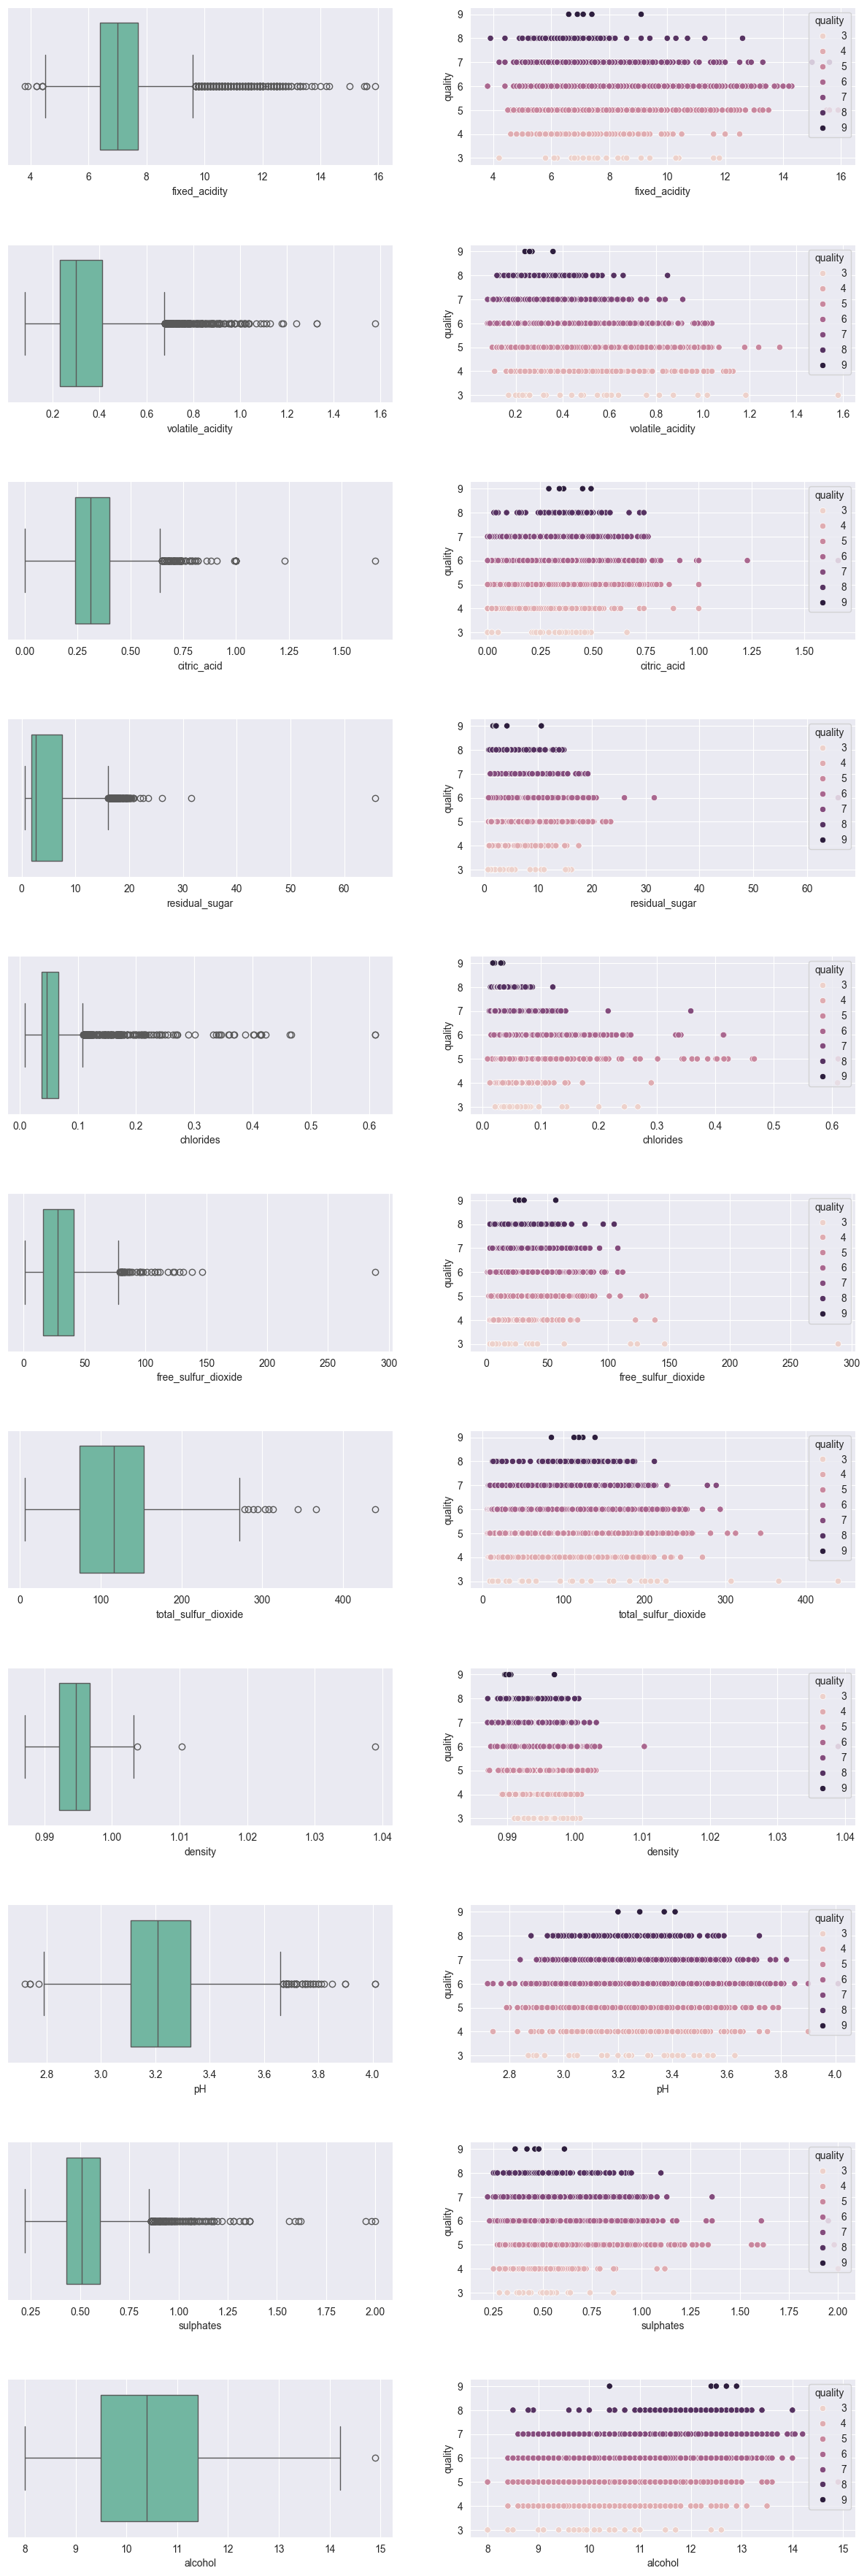

In [135]:
fig, ax = plt.subplots(11, 2, figsize=(15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    # Boxplot
    sns.boxplot(x=columns[i], data=data, ax=ax[i, 0])
    # Scatter
    sns.scatterplot(x=columns[i], y='quality', data=data, hue='quality', ax=ax[i, 1])

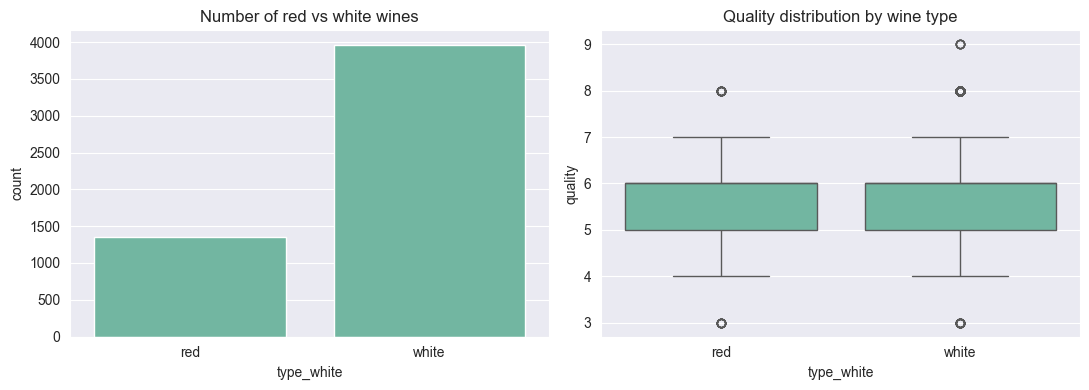

In [136]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

#count of red vs white
sns.countplot(x='type_white', data=data, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['red', 'white'])
ax[0].set_title('Number of red vs white wines')

#quality distribution by wine type
sns.boxplot(x='type_white', y='quality', data=data, ax=ax[1])
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['red', 'white'])
ax[1].set_title('Quality distribution by wine type')

plt.tight_layout()
plt.show()

<strong> <h2>  1. Outliers & Skewed Features </h2> </strong>
```
+ Right-skewed features with high outliers
  residual sugar, chlorides, free sulfur dioxide,
  total sulfur dioxide, sulphates
```

Most wines fall in a compact central range, but a small subset shows unusually large values.

```
= Tightly distributed features
  density, pH
```

---

<strong> <h2>2. Feature–Quality Relationships </h2></strong>
<strong> Clear Positive Relationship  </strong>
```
+ Alcohol  →  Quality increases as alcohol increases
```

<strong>Clear Negative Relationship</strong>
```
- Volatile acidity  →  Quality decreases as volatility increases
```
Lower volatility aligns with medium to high quality scores.

<strong>Slight Positive Association</strong>

```
+ Citric acid      → weak upward trend with quality
+ Sulphates        → weak upward trend with quality
```
Higher values appear more often in better-rated wines, but the effect is mild.

<strong>Little or No Clear Pattern</strong>
```
= Residual sugar
= Sulfur dioxide (free & total)
= Density
```

Quality points are spread across almost the full value ranges.

---

<strong><h2>3. Red vs. White Wines</h2></strong>
<strong>Dataset Composition</strong>
```
+ More white wines than red wines in the dataset
```

<strong>Quality Distribution Comparison</strong>
```
= Red and white wines show similar medians and IQRs
```

---

| Feature Group           | Features                                                  | Visual Pattern              | Association With Quality       |
| ----------------------- | --------------------------------------------------------- | --------------------------- | ------------------------------ |
| **Skewed / Outliers**   | residual sugar, chlorides, free SO₂, total SO₂, sulphates | Wide range, long right tail | Mostly weak or unclear         |
| **Tightly Distributed** | density, pH                                               | Very narrow range           | Weak / none                    |
| **Strong Positive**     | alcohol                                                   | Clear upward trend          | Higher values → higher quality |
| **Strong Negative**     | volatile acidity                                          | Clear downward trend        | Higher values → lower quality  |
| **Weak Positive**       | citric acid, sulphates                                    | Slight upward trend         | Mild association               |
| **No Clear Pattern**    | residual sugar, SO₂, density                              | Scattered                   | None                           |


# Plotting the data

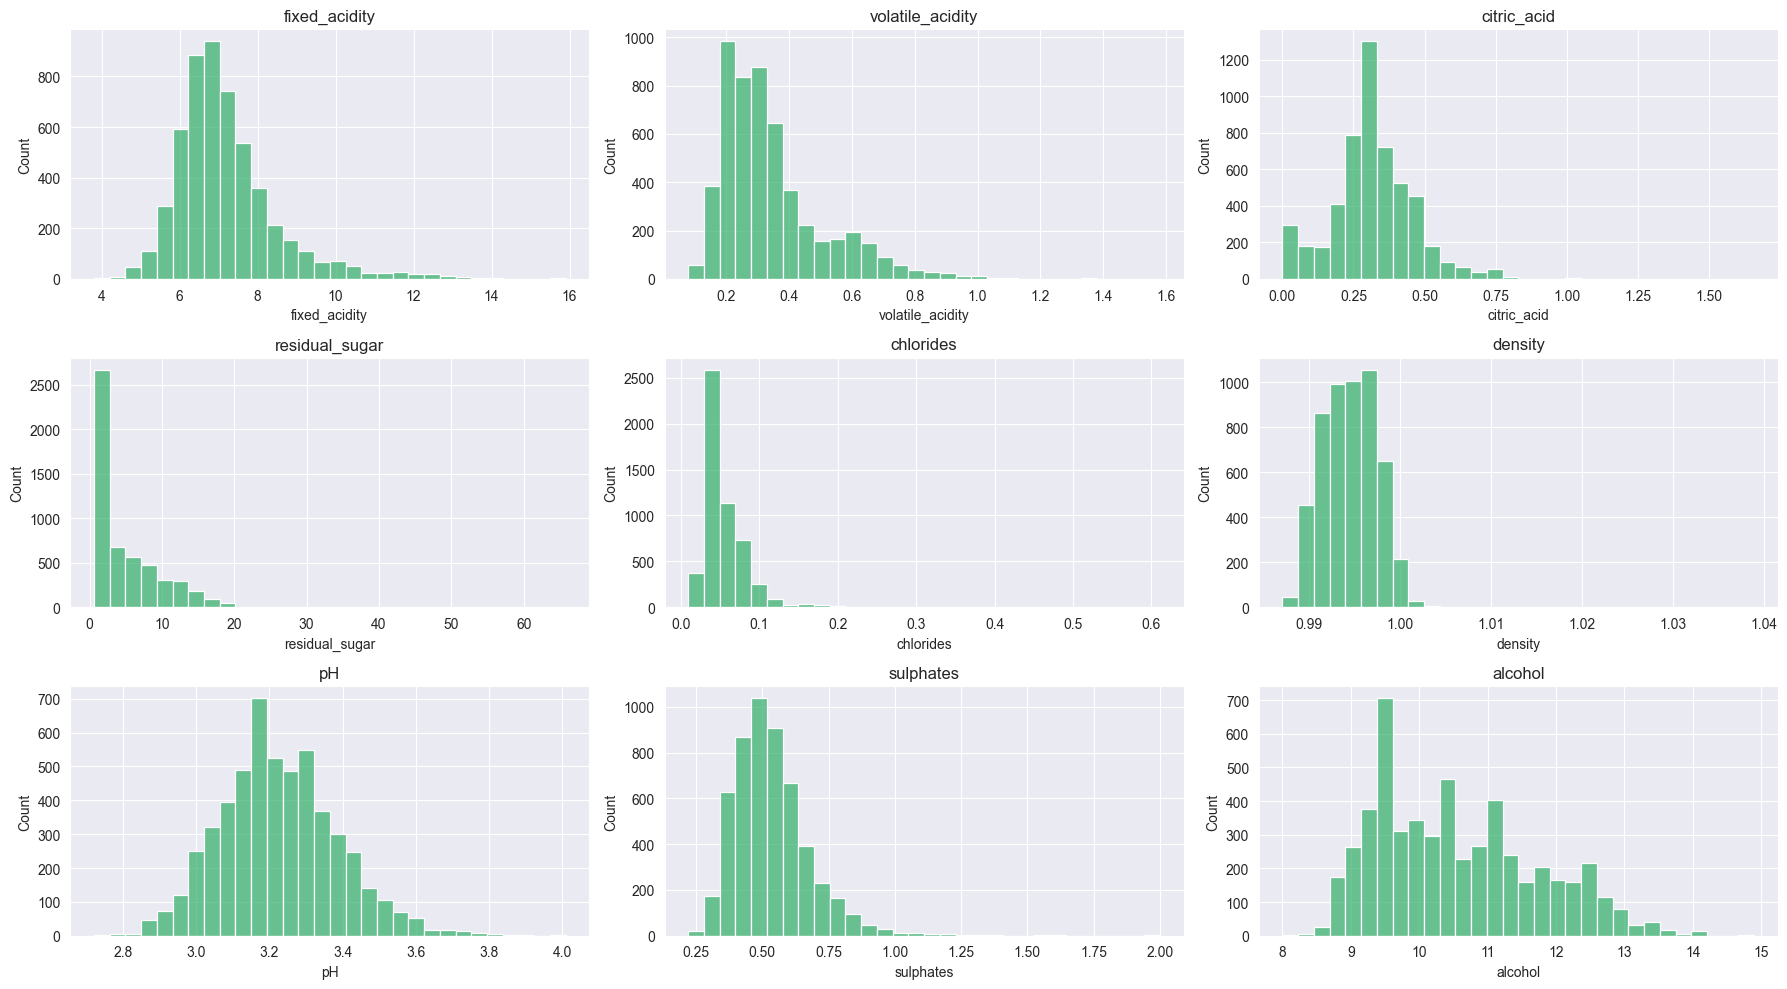

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["fixed_acidity", "volatile_acidity", "citric_acid", 
                "residual_sugar", "chlorides", "density", "pH",
                "sulphates", "alcohol"]

plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], bins=30, kde=False, color="mediumseagreen")
    plt.title(col, fontsize=12)
plt.tight_layout()
plt.show()

# **Why We Apply Feature Scaling**

```
 ┌──────────────────────────────────────────────────────────┐
 │                   1. Feature Scale Issues                 │
 └──────────────────────────────────────────────────────────┘
        • Features span very different numeric ranges
              - residual sugar → can exceed 60 g/dm³
              - pH → stays between 2.8 and 4.0
              - alcohol → measured in %
              - chlorides → close to 0
        • Raw values are not directly comparable
```

```
 ┌──────────────────────────────────────────────────────────┐
 │                  2. Skewness & Outliers                  │
 └──────────────────────────────────────────────────────────┘
        • Several predictors are right-skewed
              residual sugar, chlorides, sulphates,
              sulfur dioxide
        • Long-tailed distributions increase variance
```

```
 ┌──────────────────────────────────────────────────────────┐
 │        3. Impact on ML Models (Without Scaling)          │
 └──────────────────────────────────────────────────────────┘
        • Models affected:
              Logistic Regression, KNN, SVM
        • Features with large ranges dominate:
              - Gradient calculations (LogReg, SVM)
              - Distance calculations (KNN, SVM)
        • Model weights become unbalanced
```

```
 ┌──────────────────────────────────────────────────────────┐
 │                4. Scaling as the Solution                 │
 └──────────────────────────────────────────────────────────┘
        • Apply StandardScaler:
              mean → 0
              variance → 1
        • All features become comparable in scale
        • Improves model stability and fairness across
          predictors
```




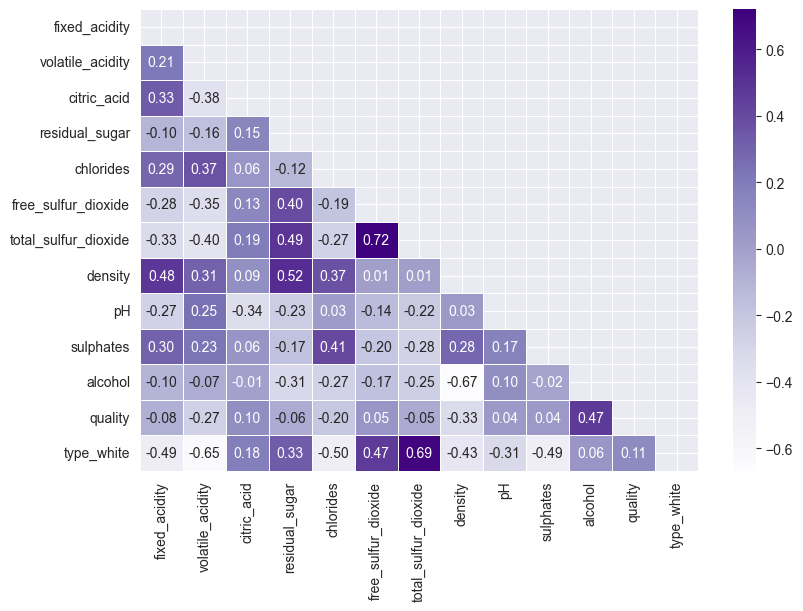

In [138]:
corr = data.corr()
# cmap = sns.diverging_palette(-1, 1, s=100, l=50, n=15, center="dark", as_cmap=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=0.5, cmap='Purples', mask=np.triu(corr))
plt.show()


# **Dropping One of the SO₂ Features**

## **Reason for Removal**

```
Two SO₂ features are highly correlated:
    • free_sulfur_dioxide
    • total_sulfur_dioxide  (includes the free portion)
```

Their strong correlation (ρ ≈ 0.72) indicates they carry **overlapping information**.
Keeping both introduces **multicollinearity**, especially in linear models.

```
Decision:
    Drop  → free_sulfur_dioxide
    Keep  → total_sulfur_dioxide (more general measure)
```

This reduces redundancy and simplifies the feature space.

---

# **Key Insights From the Correlation Matrix**

```
1. Alcohol — strongest positive correlation with quality (≈ 0.47)
       Higher alcohol content generally corresponds to higher wine quality.
```

```
2. Volatile acidity — moderate negative correlation with quality (≈ −0.27)
       Higher volatility is associated with lower quality ratings.
```

```
3. Sulphates and citric acid — weak positive correlations with quality
       Slight contributors to better ratings.
```

```
4. Density — closely related to residual sugar and total sulfur dioxide
       Consistent with physical effects of dissolved substances on density.
```

```
5. type_white — strongly correlated with multiple chemical variables
       Highlights clear chemical differences between red and white wines.
```

---


In [139]:
data = data.drop(columns='free_sulfur_dioxide')

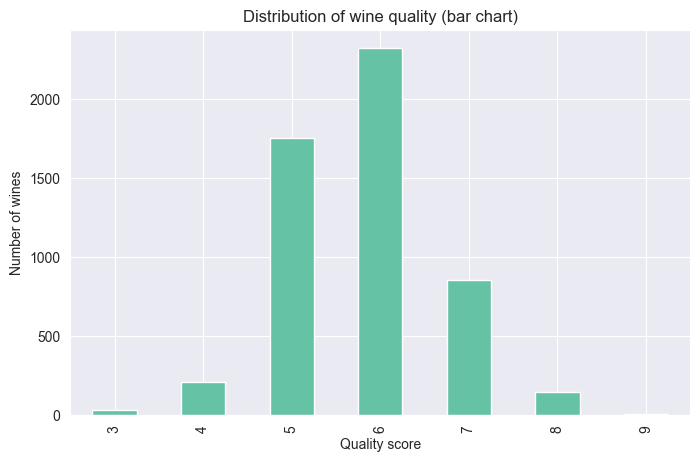

In [140]:
plt.figure(figsize=(8, 5))
data["quality"].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.title("Distribution of wine quality (bar chart)")
plt.show()

<p>
The bar chart shows that most wines have quality scores between <b>5</b> and <b>7</b>, 
with relatively few very low (3–4) or very high (8–9) ratings.  
For our classification task, we simplify this ordinal scale into a
<b>binary target</b>:
</p>

<ul>
  <li><b>1 – HighQuality:</b> wines with a quality score from <code>6</code> to <code>9</code></li>
  <li><b>0 – LowQuality:</b> wines with a quality score from <code>3</code> to <code>5</code></li>
</ul>

<p>
This transformation turns the problem into “<i>is this wine high quality or not?</i>” 
and makes the classes more balanced while keeping the interpretation clear.
The exact mapping is implemented later in the section <b>Target Categorizing</b>.
</p>

In [146]:
plot_df = data[['type_white', 'quality', 'alcohol', 'density', 'pH', 'citric_acid', 'residual_sugar']].copy()

# quality level: 3–5 = low, 6–9 = high (TEMP column)
plot_df['quality_level'] = np.where(
    plot_df['quality'].between(6, 9),
    'High quality (6–9)',
    'Low quality (3–5)'
)

# wine type from type_white (TEMP column)
plot_df['wine_type'] = np.where(
    plot_df['type_white'] == 1,
    'white',
    'red'
)

# bin numeric features into low / medium / high (TEMP columns)
plot_df['alcohol_bin']        = pd.qcut(plot_df['alcohol'],        q=3, labels=['low', 'medium', 'high'])
plot_df['density_bin']        = pd.qcut(plot_df['density'],        q=3, labels=['low', 'medium', 'high'])
plot_df['pH_bin']             = pd.qcut(plot_df['pH'],             q=3, labels=['low', 'medium', 'high'])
plot_df['citric_acid_bin']    = pd.qcut(plot_df['citric_acid'],    q=3, labels=['low', 'medium', 'high'])
plot_df['residual_sugar_bin'] = pd.qcut(plot_df['residual_sugar'], q=3, labels=['low', 'medium', 'high'])

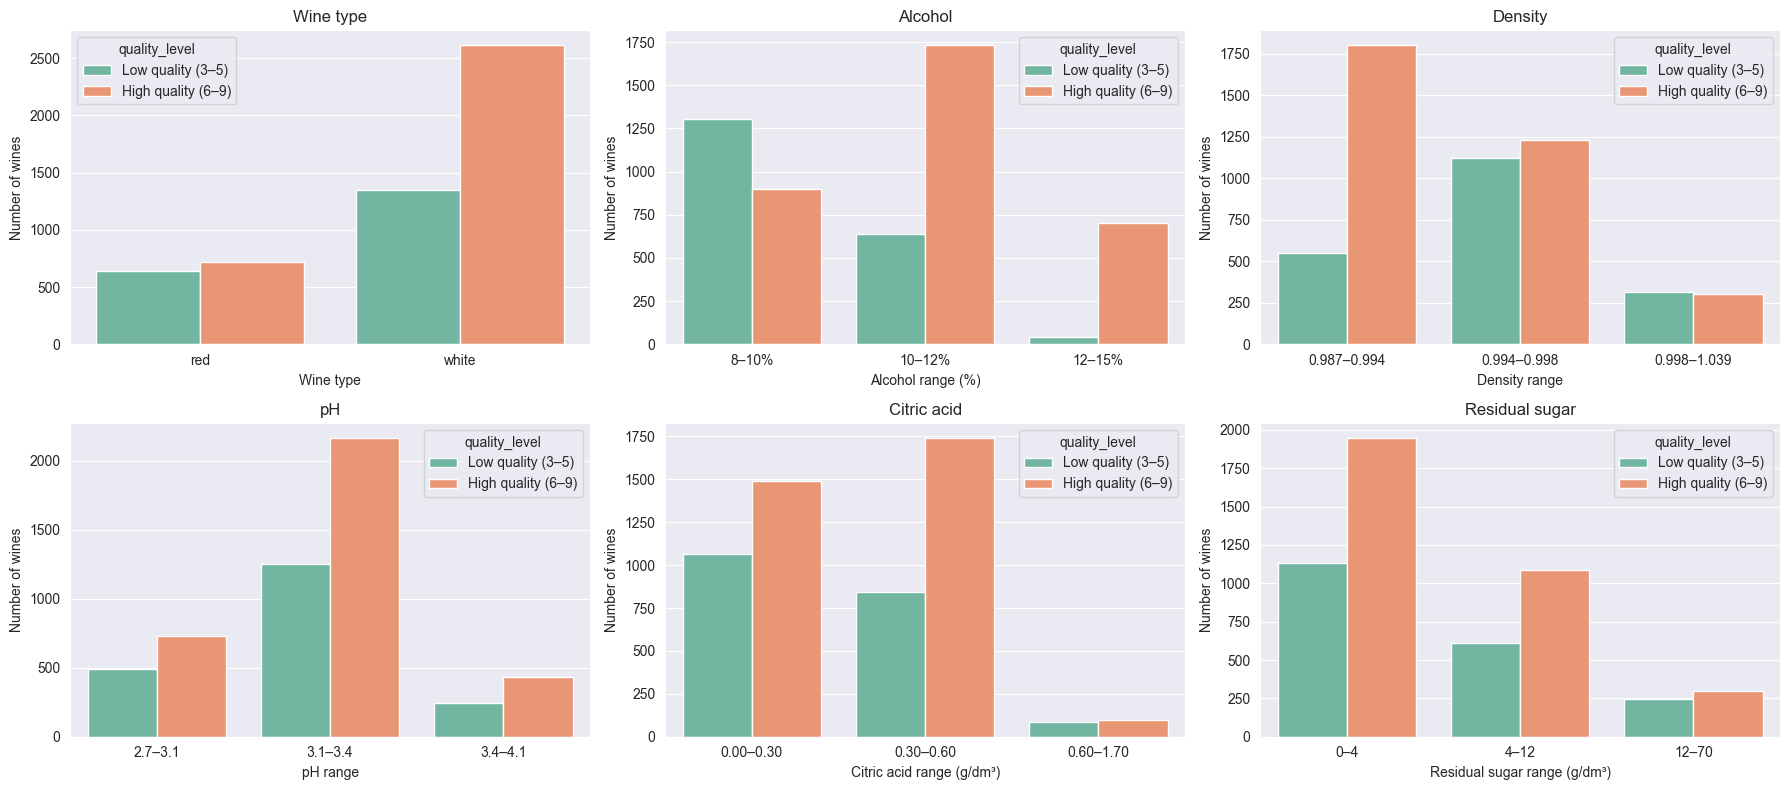

In [155]:
# subplots type, alcohol, density, pH, citric acid, residual sugar
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

# 1) Wine type
sns.countplot(
    data=plot_df,
    x='wine_type',
    hue='quality_level',
    ax=axes[0]
)
axes[0].set_title('Wine type')
axes[0].set_xlabel('Wine type')
axes[0].set_ylabel('Number of wines')

# 2) Alcohol
sns.countplot(
    data=plot_df,
    x='alcohol_bin',
    hue='quality_level',
    ax=axes[1]
)
axes[1].set_title('Alcohol')
axes[1].set_xlabel('Alcohol range (%)')
axes[1].set_ylabel('Number of wines')

# 3) Density
sns.countplot(
    data=plot_df,
    x='density_bin',
    hue='quality_level',
    ax=axes[2]
)
axes[2].set_title('Density')
axes[2].set_xlabel('Density range')
axes[2].set_ylabel('Number of wines')

# 4) pH
sns.countplot(
    data=plot_df,
    x='pH_bin',
    hue='quality_level',
    ax=axes[3]
)
axes[3].set_title('pH')
axes[3].set_xlabel('pH range')
axes[3].set_ylabel('Number of wines')

# 5) Citric acid
sns.countplot(
    data=plot_df,
    x='citric_acid_bin',
    hue='quality_level',
    ax=axes[4]
)
axes[4].set_title('Citric acid')
axes[4].set_xlabel('Citric acid range (g/dm³)')
axes[4].set_ylabel('Number of wines')

# 6) Residual sugar
sns.countplot(
    data=plot_df,
    x='residual_sugar_bin',
    hue='quality_level',
    ax=axes[5]
)
axes[5].set_title('Residual sugar')
axes[5].set_xlabel('Residual sugar range (g/dm³)')
axes[5].set_ylabel('Number of wines')


plt.tight_layout()
plt.show()


<table>
  <tr>
    <td style="vertical-align: top; width: 50%; padding-right: 20px;">
      <h3>1. Wine Type (Red vs White)</h3>
      <table>
        <tr><th>Observation</th><th>Description</th></tr>
        <tr><td>Quality distribution</td><td>Both types have more high-quality (6–9) wines than low-quality ones.</td></tr>
        <tr><td>Dataset balance</td><td>White wines are more numerous overall.</td></tr>
        <tr><td>High-quality counts</td><td>White wines contain the largest number of high-quality samples.</td></tr>
      </table>
    </td>
    <td style="vertical-align: top; width: 50%; padding-left: 20px;">
      <h3>2. Alcohol Range (%)</h3>
      <table>
        <tr><th>Alcohol Range</th><th>Dominant Quality</th><th>Interpretation</th></tr>
        <tr><td>8–10%</td><td>Low-quality</td><td>Lower alcohol → lower quality tendency</td></tr>
        <tr><td>10–12%</td><td>High-quality</td><td>Alcohol positively associated with quality</td></tr>
        <tr><td>12–15%</td><td>Strongly high-quality</td><td>Highest alcohol → best quality patterns</td></tr>
      </table>
    </td>
  </tr>
</table>

<table>
  <tr>
    <td style="vertical-align: top; width: 50%; padding-right: 20px;">
      <h3>3. Density Range</h3>
      <table>
        <tr><th>Density Range</th><th>Dominant Quality</th><th>Interpretation</th></tr>
        <tr><td>0.987–0.994</td><td>High-quality</td><td>Lower density → more alcohol / less sugar</td></tr>
        <tr><td>0.994–0.998</td><td>Low-quality</td><td>Higher density linked to lower quality</td></tr>
        <tr><td>&gt;0.998</td><td>Mixed / rare</td><td>No strong separation</td></tr>
      </table>
    </td>
    <td style="vertical-align: top; width: 50%; padding-left: 20px;">
      <h3>4. pH Range</h3>
      <table>
        <tr><th>pH Range</th><th>Dominant Quality</th><th>Interpretation</th></tr>
        <tr><td>2.7–3.1</td><td>Mixed</td><td>Few wines, no clear trend</td></tr>
        <tr><td><b>3.1–3.4</b></td><td><b>High-quality</b></td><td>Optimal acidity range for better wines</td></tr>
        <tr><td>3.4–4.1</td><td>Mixed</td><td>Less common, no strong trend</td></tr>
      </table>
    </td>
  </tr>
</table>

<table>
  <tr>
    <!-- TABLE 5: Citric Acid -->
    <td style="vertical-align: top; width: 50%; padding-right: 20px;">
      <h3>5. Citric Acid Range (g/dm³)</h3>
      <table>
        <tr><th>Citric Acid Range</th><th>Dominant Quality</th><th>Interpretation</th></tr>
        <tr><td>0.00–0.30</td><td>Low-quality</td><td>Very low citric acid linked to lower quality</td></tr>
        <tr><td>0.30–0.60</td><td>High-quality</td><td>Moderate citric acid → better wines</td></tr>
        <tr><td>0.60–1.70</td><td>Slightly high-quality</td><td>Rare values but still lean positive</td></tr>
      </table>
    </td>
    <!-- TABLE 6: Residual Sugar -->
    <td style="vertical-align: top; width: 50%; padding-left: 20px;">
      <h3>6. Residual Sugar Range (g/dm³)</h3>
      <table>
        <tr><th>Sugar Range</th><th>Dominant Quality</th><th>Interpretation</th></tr>
        <tr><td>0–4</td><td>Slightly high-quality</td><td>Most wines here; weak separation</td></tr>
        <tr><td>4–12</td><td>Mixed</td><td>No strong quality distinction</td></tr>
        <tr><td>12–70</td><td>Mixed</td><td>Very sweet wines → not strongly tied to quality</td></tr>
      </table>
    </td>
  </tr>
</table>





<h2><b><span>🍷 Step 3.4 : </span><span>Target Categorizing</span></b></h2>

In [156]:
data = data.replace({'quality' : {  9 : 1,#HighQuality
                                    8 : 1,
                                    7 : 1,
                                    6 : 1,
                                    5 : 0,#LowQuality
                                    4 : 0,
                                    3 : 0,
        }}
)

In [157]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,0,0
1,7.8,0.88,0.00,2.6,0.098,67.0,0.9968,3.20,0.68,9.8,0,0
2,7.8,0.76,0.04,2.3,0.092,54.0,0.9970,3.26,0.65,9.8,0,0
3,11.2,0.28,0.56,1.9,0.075,60.0,0.9980,3.16,0.58,9.8,1,0
5,7.4,0.66,0.00,1.8,0.075,40.0,0.9978,3.51,0.56,9.4,0,0


In [158]:
data["quality"].value_counts()

quality
1    3332
0    1988
Name: count, dtype: int64

<p>
After binarizing the target, the class distribution is:
</p>

<ul>
  <li><b>1 (HighQuality)</b>: 3332 samples</li>
  <li><b>0 (LowQuality)</b>: 1988 samples</li>
</ul>

<p>
This means the dataset is <b>moderately imbalanced</b> (about 63% vs 37%).
When training our models, we will take this into account (e.g., by using 
class weights and metrics such as F1-score and ROC–AUC instead of relying
only on accuracy).
</p>


<h2><b><span>🍷 Step 3.5 : </span><span>Scaling</span></b></h2>

<p>
As we see from the histograms, the numerical features lie on very different
value ranges and several of them contain clear outliers and right-skewed
distributions (e.g., residual sugar, chlorides, sulphates).
To make the features comparable and to reduce the influence of extreme values
on models such as Logistic Regression, KNN and SVM, we will apply
<b>feature scaling</b> (standardization with <code>StandardScaler</code>)
in the preprocessing step.
</p>


In [159]:
# Create X from DataFrame and y as Target
X_temp = data.drop(columns=['quality'])
y = data.quality

In [160]:
num_cols = [c for c in X_temp.columns if c != 'type_white']

scaler = StandardScaler()
X_temp[num_cols] = scaler.fit_transform(X_temp[num_cols])

X = X_temp

X.describe().T.style.background_gradient(axis=0, cmap='Purples')

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,5320.000000,0.000000,1.000094,-2.588145,-0.617772,-0.163070,0.367415,6.581671
volatile_acidity,5320.000000,-0.000000,1.000094,-1.570028,-0.678405,-0.262314,0.391543,7.346207
citric_acid,5320.000000,0.000000,1.000094,-2.164515,-0.533454,-0.057728,0.553919,9.116989
residual_sugar,5320.000000,0.000000,1.000094,-0.988604,-0.721923,-0.521912,0.544812,13.501067
chlorides,5320.000000,0.000000,1.000094,-1.293816,-0.507052,-0.262884,0.252582,15.038318
total_sulfur_dioxide,5320.000000,-0.000000,1.000094,-1.904371,-0.706532,0.033310,0.689479,5.740662
density,5320.000000,0.000000,1.000094,-2.504125,-0.787562,0.038682,0.753636,14.988637
pH,5320.000000,0.000000,1.000094,-3.146985,-0.715020,-0.091439,0.656858,4.897208
sulphates,5320.000000,-0.000000,1.000094,-2.092831,-0.690295,-0.155996,0.445090,9.795325
alcohol,5320.000000,0.000000,1.000094,-2.149768,-0.884822,-0.125855,0.717443,3.668983


After applying **StandardScaler** to all numerical features (except `type_white`):

- Each continuous variable now has **mean ≈ 0** and **standard deviation ≈ 1**,  
  which makes them comparable in scale and suitable for models sensitive to feature magnitude  
  (Logistic Regression, KNN, SVM, etc.).
- The value ranges of the scaled features are roughly from **about −3 to +7–15**,  
  reflecting former outliers but now in standardized units (z-scores).
- The binary feature **`type_white`** remains in its original 0/1 form  
  (mean ≈ 0.74, std ≈ 0.44), since it is not transformed by the scaler.

Overall, the dataset is now **properly scaled**, reducing the dominance of any single feature
due to its original units or range.



<h1><b><span>🍷 Step 4 : </span><span>Modeling</span></b></h1>

<h2><b><span>🍷 Step 4.1 : </span><span>Initialization</span></b></h2>

In [161]:
features = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates',
       'alcohol', 'type_white']
X = data[features]
y = data['quality']

In [162]:
# Splite Dataframe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

<h2><b><span>🍷 Step 4.2 : </span><span>Logistic Regression</span></b></h2>

In [163]:
#Parameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2'] 
}

log_reg = LogisticRegression(random_state=42, max_iter=2000)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(log_reg, param_grid, cv=cv, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_log_reg = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [164]:

#Evaluating tuned model
y_pred = best_log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_log_reg.predict_proba(X_test)[:, 1])

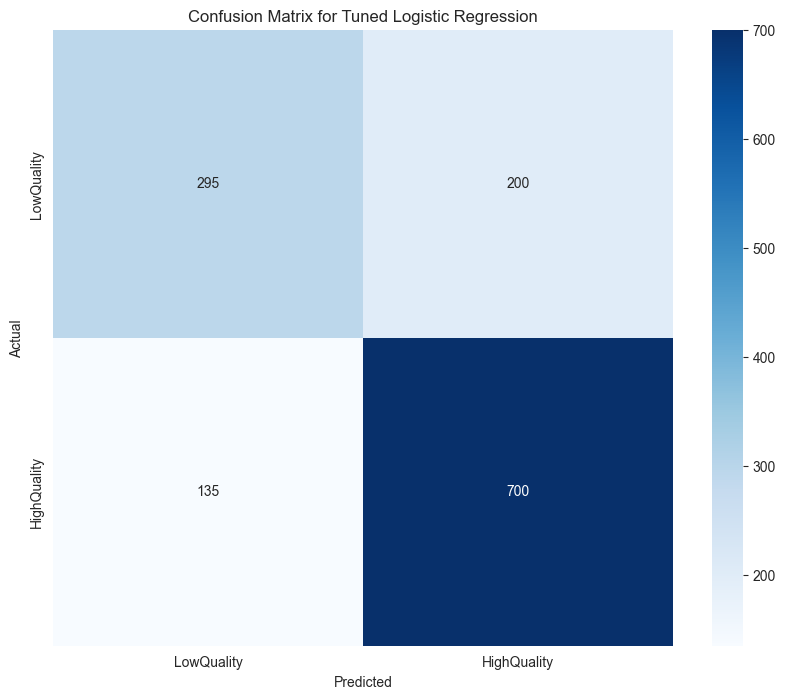

In [165]:
#Plotting confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["LowQuality", "HighQuality"], yticklabels=["LowQuality", "HighQuality"])
plt.title("Confusion Matrix for Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

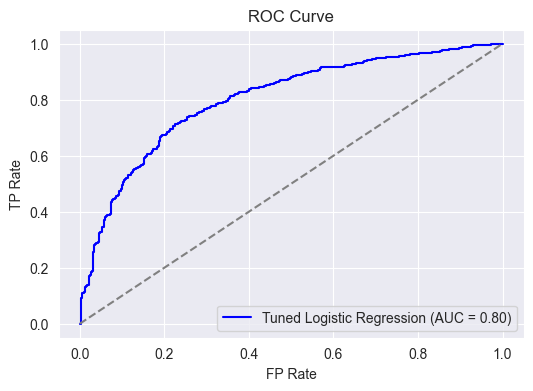

In [166]:
#Plotting ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_test, best_log_reg.predict_proba(X_test)[:, 1])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'Tuned Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#Metrics
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(class_report)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.7481203007518797

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       495
           1       0.78      0.84      0.81       835

    accuracy                           0.75      1330
   macro avg       0.73      0.72      0.72      1330
weighted avg       0.74      0.75      0.74      1330


ROC-AUC Score: 0.8020685900925422



---

###  Conclusion – Logistic Regression
- **Model & tuning.**  
  Logistic Regression was tuned with `GridSearchCV` using 5-fold `StratifiedKFold` and ROC–AUC
  as the scoring metric.  
  The best hyperparameters are:
  - `C = 100`, `penalty = 'l2'`, `solver = 'lbfgs'`.

- **Overall performance (test set).**
  - **Accuracy:** ≈ **0.75**
  - **ROC–AUC:** ≈ **0.80**
  - The ROC curve lies well above the diagonal, indicating that the model separates
    high- vs low-quality wines much better than random.

- **Class-wise metrics.**

| Class           | Precision | Recall | F1-score | Interpretation                         |
| --------------- | --------- | ------ | -------- | -------------------------------------- |
| LowQuality (0)  | 0.69      | 0.60   | 0.64     | Model struggles more here              |
| HighQuality (1) | 0.78      | 0.84   | 0.81     | Strong detection of high-quality wines |

- **Confusion matrix interpretation.**
  - Correctly predicts **295** low-quality and **700** high-quality wines.
  - Misclassifies **200** low-quality wines as high-quality (false positives).
  - Misclassifies **135** high-quality wines as low-quality (false negatives).

**Conclusion:**  
The tuned logistic regression model performs **solidly** on this task.  
It is especially good at detecting **high-quality wines** (recall ≈ 84%), while performance
on low-quality wines is slightly weaker but still reasonable.


In [49]:
# 1. Probabilities of class 1 ("HighQuality")
idx_pos = list(best_log_reg.classes_).index(1)
y_probs = best_log_reg.predict_proba(X_test)[:, idx_pos]

# 2. Scan thresholds
thresholds = np.linspace(0, 1, 200)

tps, fps, fns, tns = [], [], [], []
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)

    # confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tps.append(tp)
    fps.append(fp)
    fns.append(fn)
    tns.append(tn)

    # metrics for positive class = 1
    precisions.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))


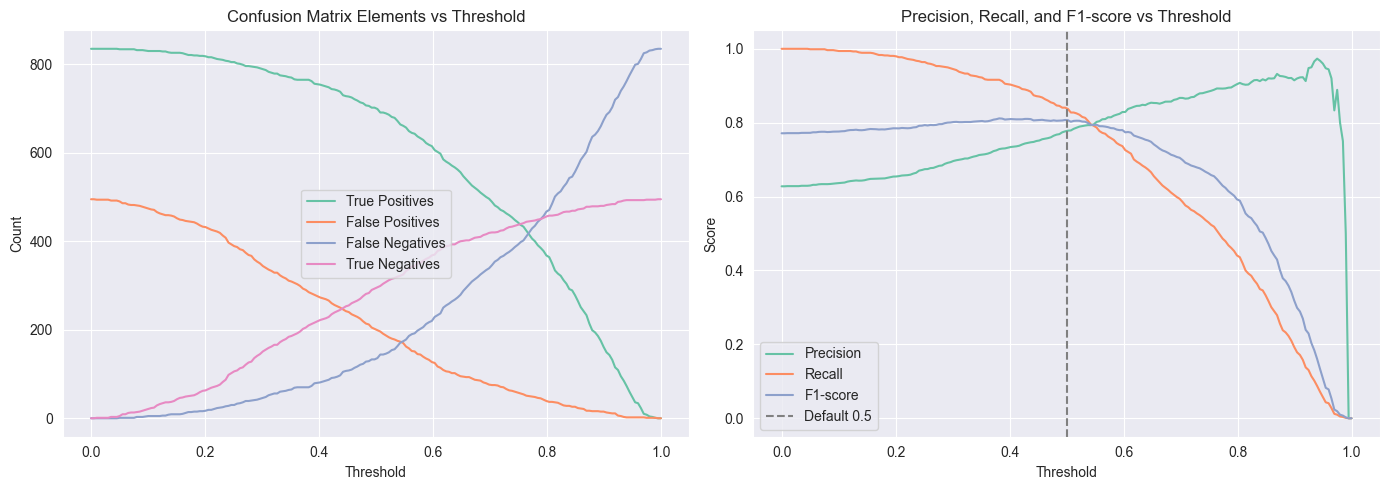

Best threshold by F1: 0.382, F1 = 0.8117


In [50]:
# 3. Plot: confusion matrix elements vs threshold  +  metrics vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TP / FP / FN / TN
axes[0].plot(thresholds, tps, label='True Positives')
axes[0].plot(thresholds, fps, label='False Positives')
axes[0].plot(thresholds, fns, label='False Negatives')
axes[0].plot(thresholds, tns, label='True Negatives')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Count')
axes[0].set_title('Confusion Matrix Elements vs Threshold')
axes[0].legend()
axes[0].grid(True)

# Right: Precision / Recall / F1
axes[1].plot(thresholds, precisions, label='Precision')
axes[1].plot(thresholds, recalls, label='Recall')
axes[1].plot(thresholds, f1s, label='F1-score')
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall, and F1-score vs Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 4. Best threshold by F1 (optional)
best_idx = np.argmax(f1s)
best_thr = thresholds[best_idx]
best_f1 = f1s[best_idx]
print(f"Best threshold by F1: {best_thr:.3f}, F1 = {best_f1:.4f}")

<h3><b>Threshold analysis for Logistic Regression</b></h3>

- The plots show how the numbers of **TP, FP, FN, TN** and the metrics
  **Precision, Recall, F1-score** change when we vary the decision threshold
  on the predicted probability of *HighQuality*.

- At the default threshold **0.5**, precision and recall are both reasonable,
  but not optimal in terms of F1.

- Scanning all thresholds, the **best F1-score is obtained around 0.38**:

| Threshold | Precision  | Recall     | F1-score             | Notes                        |
| --------- | ---------- | ---------- | -------------------- | ---------------------------- |
| 0.50      | Reasonable | Reasonable | Not optimal          | Default classifier threshold |
| **0.38**  | Balanced   | Improved   | **Highest (~0.812)** | Best point according to F1   |


- Lowering the threshold from 0.5 to **0.38** slightly increases the number of
  predicted high-quality wines, **reducing false negatives** (missed good wines)
  at the cost of a small increase in false positives.

**Conclusion:**  
| Recommended Threshold | Reason                                                                 |
| --------------------- | ---------------------------------------------------------------------- |
| **≈ 0.38**            | Provides optimal balance between precision and recall for this dataset |



<h2><b><span>🍷 Step 4.3 : </span><span>K-Neighbors Classifier</span></b></h2>

In [ ]:

accuracy_scores = []
f1_scores = []

neighbors = [5, 11, 31, 50, 100]

# 1. Считаем accuracy и F1 для каждого k
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)          # или X_train_scaled, если ты скейлишь
    y_pred = knn.predict(X_test)       # и X_test_scaled

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    accuracy_scores.append(acc)
    f1_scores.append(f1)

# 2. Выбор best_k с допуском по F1
max_f1 = max(f1_scores)
tolerance = 0.002  # все k, у которых F1 >= max_f1 - 0.002
candidate_ks = [k for k, f in zip(neighbors, f1_scores) if max_f1 - f <= tolerance]
best_k = min(candidate_ks)

# метрики для выбранного k
idx_best = neighbors.index(best_k)
best_f1 = f1_scores[idx_best]
best_acc = accuracy_scores[idx_best]

print(f"Best k (with tolerance) = {best_k}")
print(f"F1 = {best_f1:.4f}, Accuracy = {best_acc:.4f}")



Best k (with tolerance) = 31
F1 = 0.7607, Accuracy = 0.6707


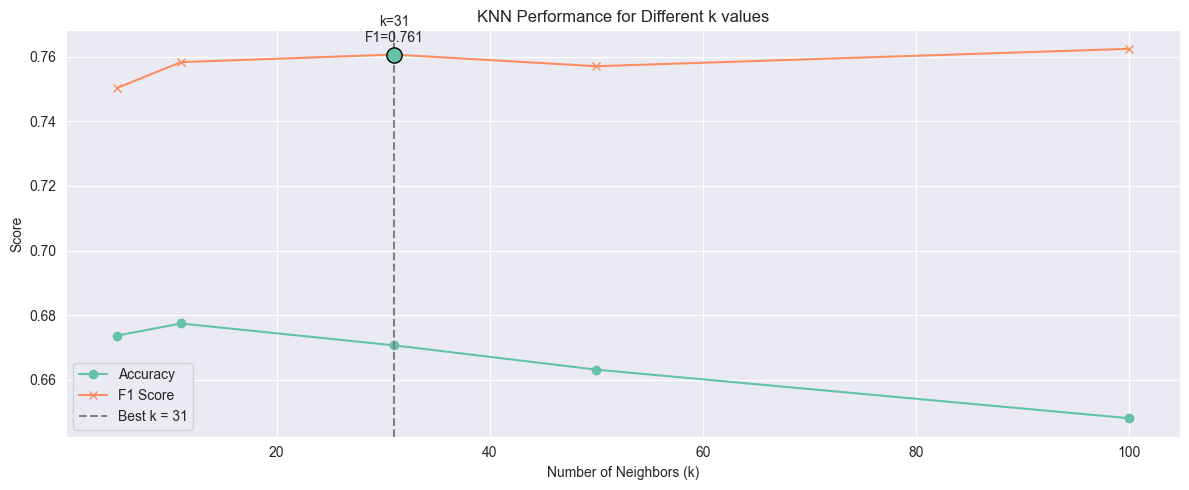

In [169]:

# 3. График
plt.figure(figsize=(12, 5))

plt.plot(neighbors, accuracy_scores, label='Accuracy', marker='o')
plt.plot(neighbors, f1_scores, label='F1 Score', marker='x')

# вертикальная линия по выбранному k
plt.axvline(x=best_k, color='gray', linestyle='--', label=f'Best k = {best_k}')

# точка лучшего F1
plt.scatter([best_k], [best_f1], s=120, edgecolors='black', zorder=5)
plt.text(best_k, best_f1 + 0.003,
         f'k={best_k}\nF1={best_f1:.3f}',
         ha='center', va='bottom')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('KNN Performance for Different k values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Initializing the model
knn = KNeighborsClassifier(n_neighbors=31)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [171]:
#Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(class_report)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.6706766917293233

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.40      0.47       495
           1       0.70      0.83      0.76       835

    accuracy                           0.67      1330
   macro avg       0.64      0.61      0.62      1330
weighted avg       0.66      0.67      0.65      1330


ROC-AUC Score: 0.7080771789753826


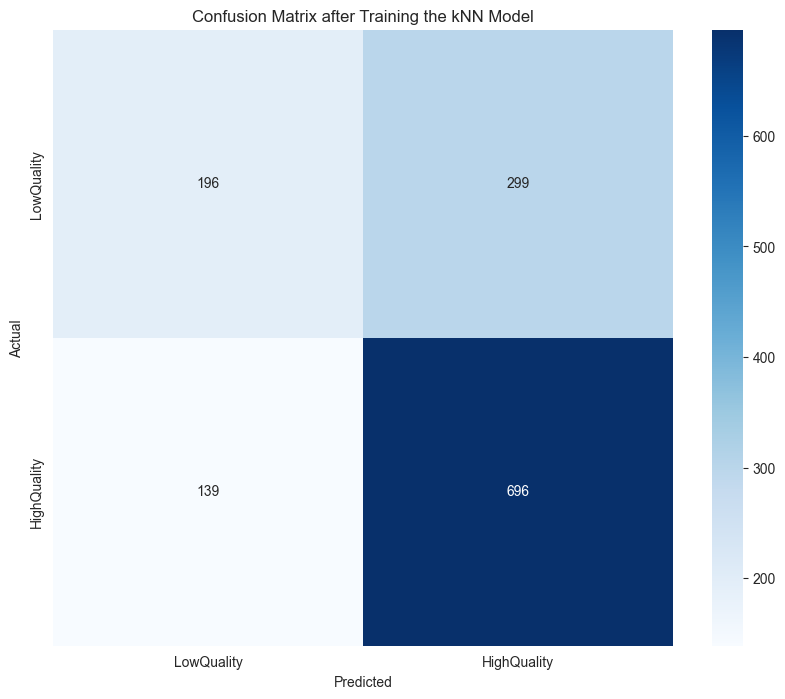

In [172]:
#Plotting confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["LowQuality", "HighQuality"], yticklabels=["LowQuality", "HighQuality"])
plt.title("Confusion Matrix after Training the kNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

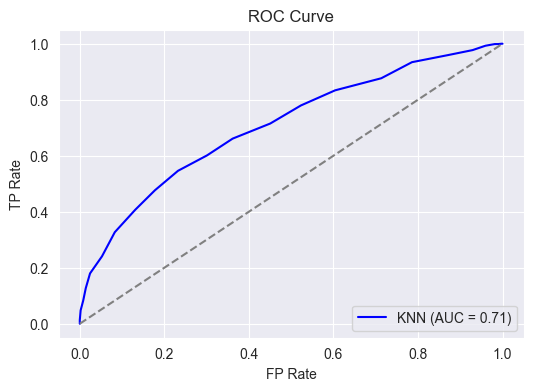

In [173]:
#Plotting ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### 🔍 Conclusion – k-NN Classifier

- We tuned the number of neighbors and found that the **best value is `k = 31`**,  
  where the model reaches **F1 ≈ 0.76** and **Accuracy ≈ 0.67**.

| Parameter | Value |
| --------- | ----- |
| Best k    | 31    |
| Accuracy  | ~0.67 |
| F1-score  | ~0.76 |
| ROC–AUC   | ~0.71 |

---

- The **classification report** shows:

| Class           | Precision | Recall | F1    | Notes              |
| --------------- | --------- | ------ | ----- | ------------------ |
| HighQuality (1) | ~0.70     | ~0.83  | ~0.76 | Strong performance |
| LowQuality (0)  | ~0.59     | ~0.40  | ~0.47 | Model struggles    |


- The **confusion matrix** confirms this pattern:

| Actual \ Predicted | Low | High     |
| ------------------ | --- | -------- |
| LowQuality         | —   | 299 (FP) |
| HighQuality        | —   | 696 (TP) |


- The **ROC–AUC score ≈ 0.71** indicates a **moderate ability** to distinguish between
  high- and low-quality wines.


| Observation                            | Interpretation                                 |
| -------------------------------------- | ---------------------------------------------- |
| Strong detection of high-quality wines | High recall for class 1                        |
| Weak detection of low-quality wines    | Many low-quality wines predicted as high       |
| Overall performance                    | Reasonable but inferior to Logistic Regression |


<h2><b><span>🍷 Step 4.4 : </span><span>SVM</span></b></h2>

In [176]:

#pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        probability=False, #note artur: off for better perfomance
        class_weight='balanced',
        random_state=42
    ))
])

param_grid = [
    {
        'svc__C': [0.1, 1, 10, 100],
        "svc__kernel": ['linear']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C' : [1, 10, 100],
        "svc__gamma": ['scale', 'auto']
    }
]

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_svc = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [177]:
# hyperparameter 

grid_svc.fit(X_train, y_train)

print("Best parameters: ", grid_svc.best_params_)
print("Best CV ROC-AUC: ", grid_svc.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:  {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV ROC-AUC:  0.8152187448515464


In [178]:
# model refit
best_params = grid_svc.best_params_.copy()


best_svc = {
    k.replace('svc__', ""): v
    for k, v in best_params.items()
    if k.startswith('svc__')
}

In [179]:
# Final pipeline
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        probability=True,
        class_weight='balanced',
        random_state=42,
        **best_svc
    ))
])

final_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [181]:

# lets evalutate
y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.8271360309683664
              precision    recall  f1-score   support

           0       0.62      0.79      0.70       495
           1       0.85      0.71      0.78       835

    accuracy                           0.74      1330
   macro avg       0.74      0.75      0.74      1330
weighted avg       0.77      0.74      0.75      1330



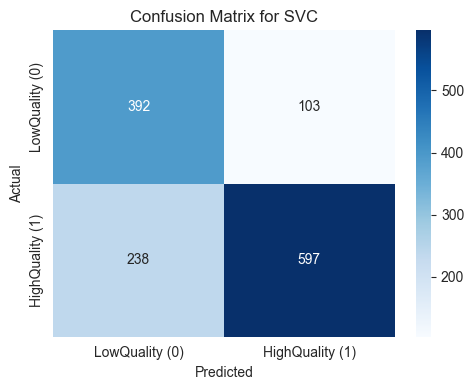

In [187]:
cm_svc = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svc,
            annot=True, fmt='d', cmap="Blues",
            xticklabels=['LowQuality (0)', 'HighQuality (1)'],
            yticklabels=['LowQuality (0)', 'HighQuality (1)'])
plt.title("Confusion Matrix for SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

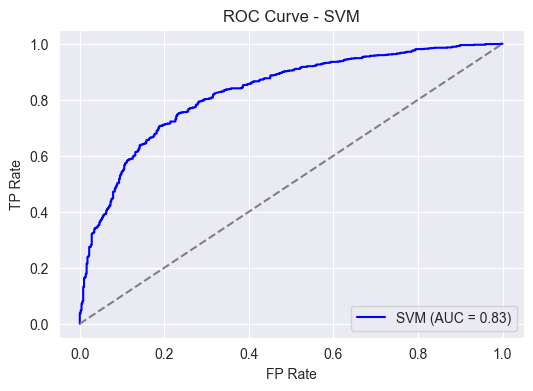

In [192]:
roc_auc = roc_auc_score(y_test, y_proba)

# Plotting ROC-AUC curve for SVM
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()

###  Support Vector Machine (SVM) – Verbal Summary

The tuned SVM model shows **strong performance** on the wine quality classification task.

---

- On the test set it reaches an **accuracy of about 74%** and a **ROC–AUC of ~0.83**.  
  The ROC curve is well above the diagonal, which means the model separates
  high- and low-quality wines much better than random guessing.


| Metric      | Value               |
| ----------- | ------------------- |
| Accuracy    | ~0.74               |
| ROC–AUC     | ~0.83               |
| Performance | Strong separability |


---

- For the **LowQuality (0)** class, the model has:
  - **Precision ≈ 0.62** – when SVM predicts “low quality”, it is correct in about 62% of cases.  
  - **Recall ≈ 0.79** – it correctly finds almost 80% of all low-quality wines.

  
- For the **HighQuality (1)** class:
  - **Precision ≈ 0.85** – predictions of “high quality” are very reliable.  
  - **Recall ≈ 0.71** – it correctly detects a bit more than 70% of all high-quality wines.

| Class           | Precision | Recall | Interpretation                         |
| --------------- | --------- | ------ | -------------------------------------- |
| LowQuality (0)  | ~0.62     | ~0.79  | Captures most low-quality wines        |
| HighQuality (1) | ~0.85     | ~0.71  | Very reliable high-quality predictions |

---


- The **confusion matrix** confirms this:
  - Most **low-quality** wines are correctly recognized (392), with relatively few
    wrongly labeled as high quality (103).
  - For **high-quality** wines, 597 are correctly classified, while 238 are missed
    and predicted as low quality.

| Actual \ Predicted | LowQuality | HighQuality |
| ------------------ | ---------- | ----------- |
| LowQuality         | 392        | 103         |
| HighQuality        | 238        | 597         |

---

**Overall conclusion:**  
The SVM model is **one of the best models** in this project.  
It gives a good balance between correctly detecting high-quality wines and not
over-labeling low-quality wines as good. Its high ROC–AUC (0.83) shows that it is
a strong classifier for this binary wine quality task.


<h2><b><span>🍷 Step 4.4 : </span><span>Random Forest Classifier</span></b></h2>

In [193]:
#Parameter tuning
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'max_leaf_nodes': [20, 30, 40],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

rf_best = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


Best Parameters: {'max_depth': None, 'max_leaf_nodes': 40, 'min_samples_split': 10, 'n_estimators': 500}


In [194]:
#Evaluating tuned model
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

In [197]:
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print("Test ROC-AUC (Random Forest):", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Test ROC-AUC (Random Forest): 0.823037561241154
              precision    recall  f1-score   support

           0       0.72      0.60      0.65       495
           1       0.78      0.86      0.82       835

    accuracy                           0.76      1330
   macro avg       0.75      0.73      0.74      1330
weighted avg       0.76      0.76      0.76      1330



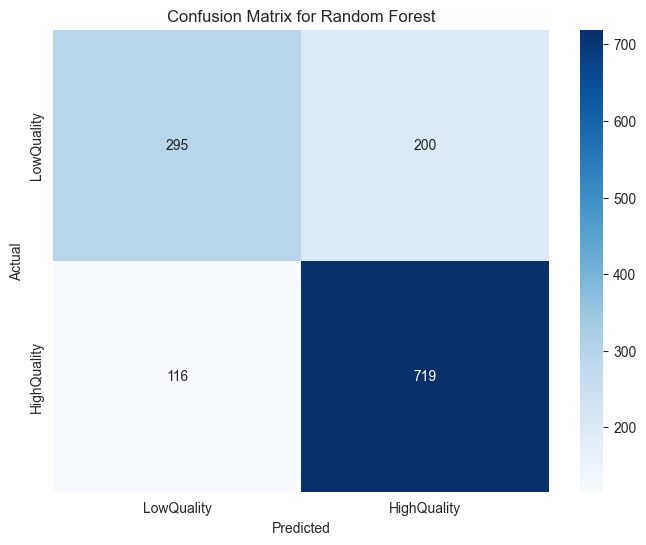

In [195]:
#Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["LowQuality", "HighQuality"], yticklabels=["LowQuality", "HighQuality"])
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

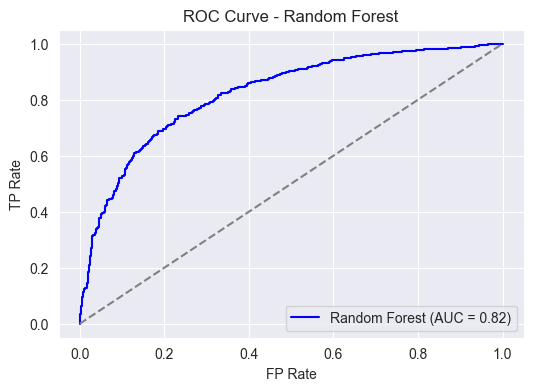

In [196]:
#Plotting ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('FP Rate')
plt.ylabel('TP Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

##   Random Forest Sumarry

---

### Overall Performance

| Metric   | Value | Interpretation                                              |
| -------- | ----- | ----------------------------------------------------------- |
| Accuracy | ~0.76 | Highest among tested models                                 |
| ROC–AUC  | ~0.82 | Strong separation between classes; close to SVM performance |

---

### Class-wise metrics
| Class               | Precision | Recall | Interpretation                                                             |
| ------------------- | --------- | ------ | -------------------------------------------------------------------------- |
| **LowQuality (0)**  | ~0.72     | ~0.60  | Good at correctly identifying low-quality wines, though recall is moderate |
| **HighQuality (1)** | ~0.78     | ~0.86  | Very strong performance; correctly detects most high-quality wines         |

---

### Confusion matrix

| Actual \ Predicted | LowQuality | HighQuality |
| ------------------ | ---------- | ----------- |
| LowQuality (0)     | 295        | 200         |
| HighQuality (1)    | 116        | 719         |

---

### Interpretation
| Observation         | Explanation                                            |
| ------------------- | ------------------------------------------------------ |
| 719 true positives  | The model correctly identifies most high-quality wines |
| 116 false negatives | Few high-quality wines are missed                      |
| 200 false positives | Some low-quality wines are mislabeled as high-quality  |
| 295 true negatives  | Many low-quality wines correctly classified            |

---

## Summary

| Aspect          | Evaluation                                                                      |
| --------------- | ------------------------------------------------------------------------------- |
| Strength        | Very strong recall for high-quality wines (excellent at not missing good wines) |
| Accuracy        | Highest among the tested models                                                 |
| Weakness        | Tends to overpredict high-quality wines (more false positives)                  |
| Overall Ranking | Among the top models in the project, comparable to SVM                          |





---

# Overall Summary

Across the four models evaluated, each showed clear strengths.
Logistic Regression proved to be a strong and interpretable baseline, performing surprisingly close to more complex models and benefiting from threshold tuning.
k-NN, while intuitive, struggled with low-quality wines and consistently underperformed compared to the others.

Among the advanced models, SVM delivered excellent separation between classes, achieving the highest ROC–AUC of all models.
However, Random Forest ultimately delivered the most balanced overall performance: the highest accuracy, strong AUC, and, crucially, the best recall for high-quality wines — a priority in this task.

Final Choice

Given the goal of avoiding missed high-quality wines while maintaining solid accuracy and ranking ability,
the tuned Random Forest stands out as the model that offers the best trade-off between all evaluation metrics.
SVM serves as a strong alternative, and Logistic Regression remains highly valuable for interpretability.

<center>

<table>
<tr>

<td style="width:25%; vertical-align: top; padding:10px;">
<h3>Logistic Regression</h3>
<ul>
<li>Accuracy ~0.75</li>
<li>AUC ~0.80</li>
<li>High F1: ~0.81</li>
<li>Threshold tuning helps</li>
<li>Interpretable coefficients</li>
</ul>
</td>

<td style="width:25%; vertical-align: top; padding:10px;">
<h3>k-NN (k = 31)</h3>
<ul>
<li>Accuracy ~0.67</li>
<li>AUC ~0.71</li>
<li>High F1: ~0.76</li>
<li>Low-quality recall weak</li>
<li>Baseline-level model</li>
</ul>
</td>

<td style="width:25%; vertical-align: top; padding:10px;">
<h3>SVM</h3>
<ul>
<li>Accuracy ~0.74</li>
<li>AUC ~0.83 (best)</li>
<li>High-quality precision ~0.85</li>
<li>Recall ~0.71</li>
<li>Strong margin-based classifier</li>
</ul>
</td>

<td style="width:25%; vertical-align: top; padding:10px;">
<h3>Random Forest</h3>
<ul>
<li>Accuracy ~0.76 (best)</li>
<li>AUC ~0.82</li>
<li>High F1: ~0.82</li>
<li>Recall ~0.86 (best)</li>
<li>Captures feature interactions</li>
</ul>
</td>

</tr>
</table>

</center>

---


<center>

<img src="https://media1.tenor.com/m/lP48pUHRi38AAAAd/merci-pour-votre-attention.gif" width="1200">

</center>

---
### Dataset

Description of the dataset used in this project

- **Source**: [Wine Quality Dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) or UCI Machine Learning Repository
- **Type**: Red Wine , White Wine 
- **Size**: Approximately 1,599 samples (red wine) or 4,898 samples (white wine)

**Course**: Introduction to Machine Learning  
**Semester**: Autumn, 2025

**University**: Kazakh-British Technical University
